### Code adopted from Polina x Tyler Final project for CV 2025/2026


  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

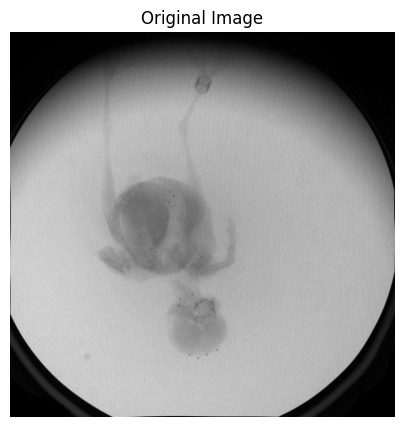

Image shape: (768, 768, 3)


In [ ]:
#test image for manual inspection
test_image_path = "C:\\Users\\Tyler Marino\\OneDrive\\Desktop\\BirdSongsMHN\\Testing\\Canaries-Test\\Data\\Cam1_Img00UND_new\\Cam1_Img00_UND.2045.jpg"

sample_img = cv2.imread(test_image_path)

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.title("Original Image")
plt.axis('off')
plt.show()

print("Image shape:", sample_img.shape)


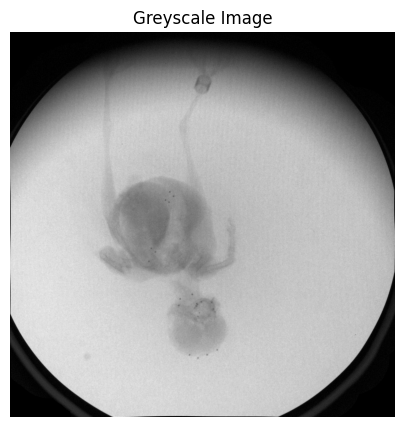

In [38]:
greyscale_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(5, 5))
plt.imshow(greyscale_img, cmap='gray')
plt.title("Greyscale Image")
plt.axis('off')
plt.show()


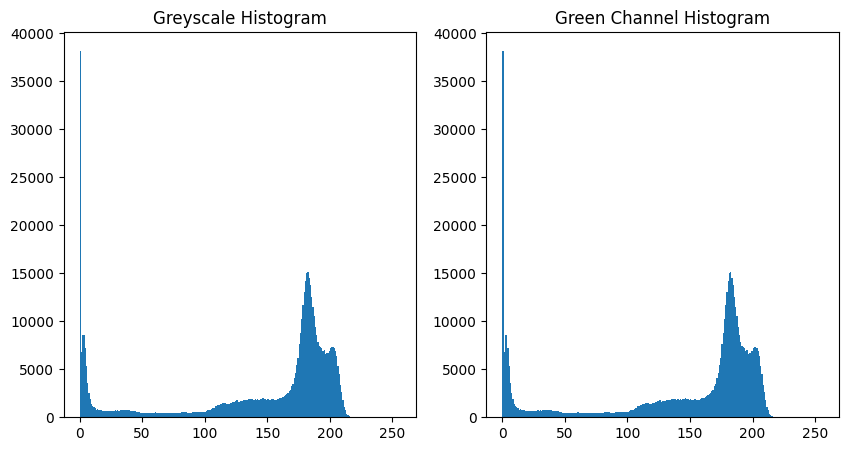

In [40]:

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(greyscale_img.ravel(), bins=256, range=(0, 256))
plt.title("Greyscale Histogram")
plt.subplot(1, 2, 2)
plt.hist(sample_img[:, :, 1].ravel(), bins=256, range=(0, 256))
plt.title("Green Channel Histogram")    
plt.show()

Max intensity in greyscale image: 236


In [ ]:
filtered_img = greyscale_img.copy())
filtered_img = filtered_img[filtered_img > 15] = 255
plt.figure(figsize=(5, 5))
plt.imshow(filtered_img, cmap='gray')   

TypeError: 'int' object does not support item assignment

# Color Space and Filters Investigation

## Filters

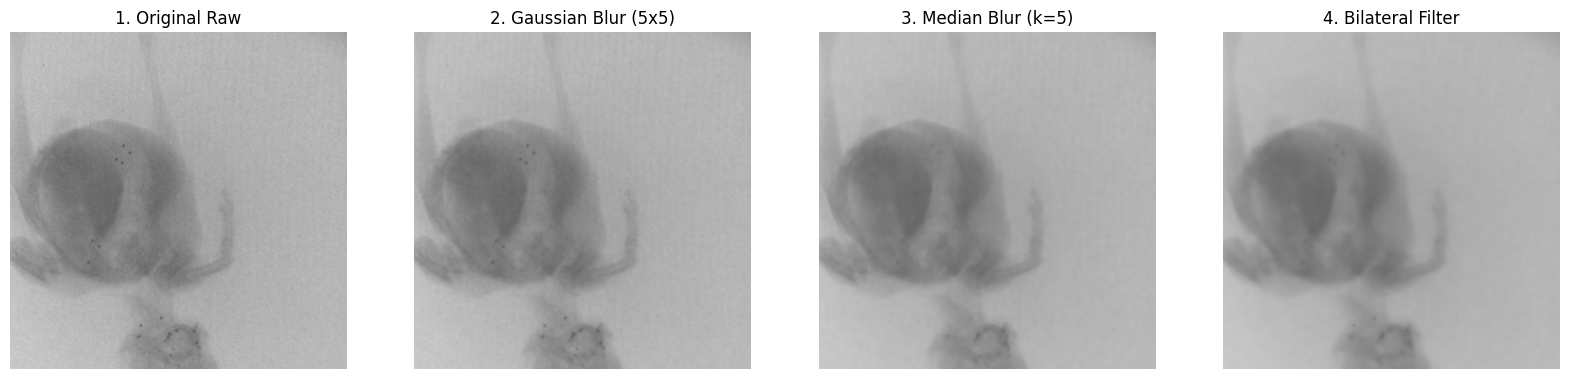

In [21]:

rgb_gauss = cv2.GaussianBlur(sample_img, (3,3), 0)

#Median Blur
rgb_median = cv2.medianBlur(sample_img, 5)

#Bilateral Filter (Texture smoothing)
rgb_bilateral = cv2.bilateralFilter(sample_img, 9, 75, 75)

# Zoom Region Selection
h, w, _ = sample_img.shape
y1, y2 = h//2 - 200, h//2 + 200
x1, x2 = w//2 - 200, w//2 + 200

fig, ax = plt.subplots(1, 4, figsize=(20, 6))
ax[0].imshow(sample_img[y1:y2, x1:x2])
ax[0].set_title("1. Original Raw")

# Gaussian
ax[1].imshow(rgb_gauss[y1:y2, x1:x2])
ax[1].set_title("2. Gaussian Blur (5x5)")

# Median
ax[2].imshow(rgb_median[y1:y2, x1:x2])
ax[2].set_title("3. Median Blur (k=5)")

# Bilateral
ax[3].imshow(rgb_bilateral[y1:y2, x1:x2])
ax[3].set_title("4. Bilateral Filter")

for a in ax: a.axis('off')
plt.show()

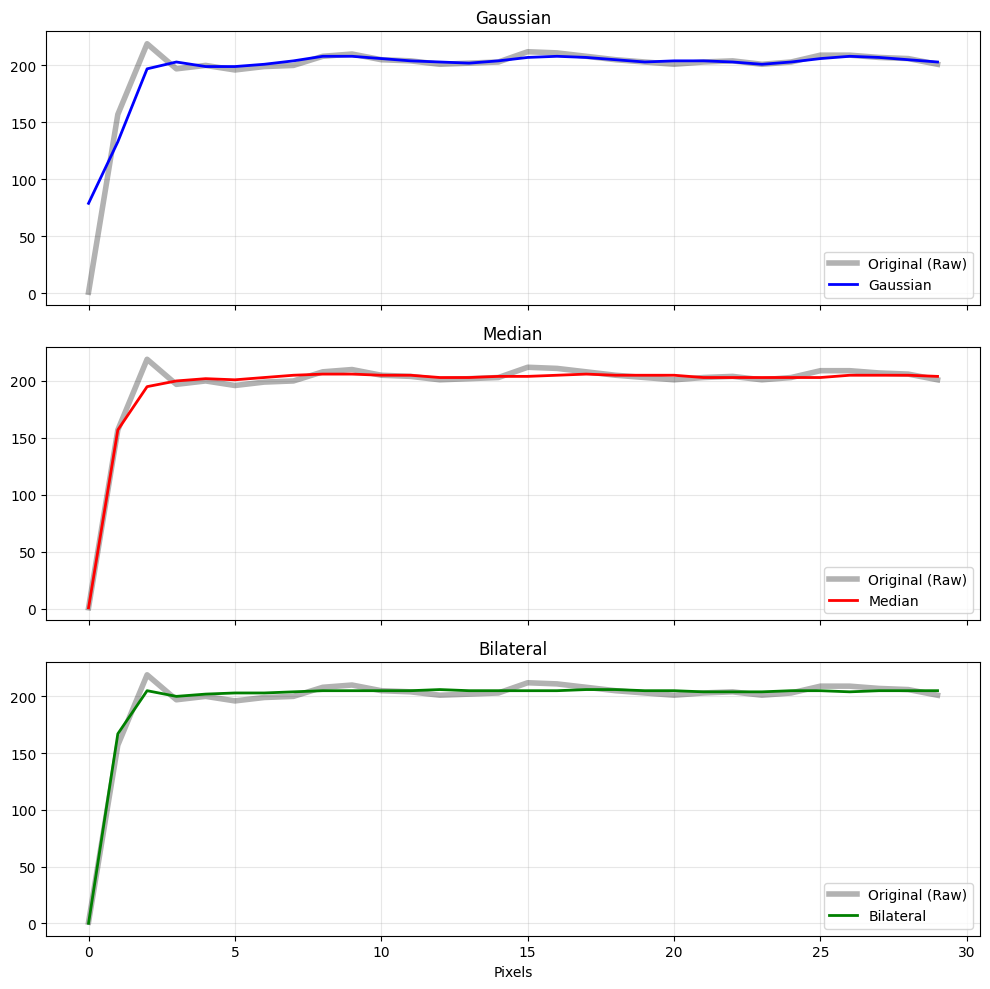

In [22]:
h, w, _ = sample_img.shape
y_coord = h // 2 

sig_raw = sample_img[y_coord, :, 1]
sig_gauss = rgb_gauss[y_coord, :, 1]
sig_med = rgb_median[y_coord, :, 1]
sig_bilat = rgb_bilateral[y_coord, :, 1]

gradient = np.abs(np.gradient(sig_raw))
edge_idx = np.argmax(gradient)

zoom_win = 30
x_start = max(0, edge_idx - zoom_win)
x_end = min(w, edge_idx + zoom_win)
x_axis = range(x_start, x_end)

fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax[0].plot(x_axis, sig_raw[x_start:x_end], 'k-', alpha=0.3, linewidth=4, label='Original (Raw)')
ax[0].plot(x_axis, sig_gauss[x_start:x_end], 'b-', linewidth=2, label='Gaussian')
ax[0].set_title("Gaussian")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(x_axis, sig_raw[x_start:x_end], 'k-', alpha=0.3, linewidth=4, label='Original (Raw)')
ax[1].plot(x_axis, sig_med[x_start:x_end], 'r-', linewidth=2, label='Median')
ax[1].set_title("Median")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(x_axis, sig_raw[x_start:x_end], 'k-', alpha=0.3, linewidth=4, label='Original (Raw)')
ax[2].plot(x_axis, sig_bilat[x_start:x_end], 'g-', linewidth=2, label='Bilateral')
ax[2].set_title("Bilateral")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.xlabel("Pixels")
plt.tight_layout()
plt.show()

## Color Space

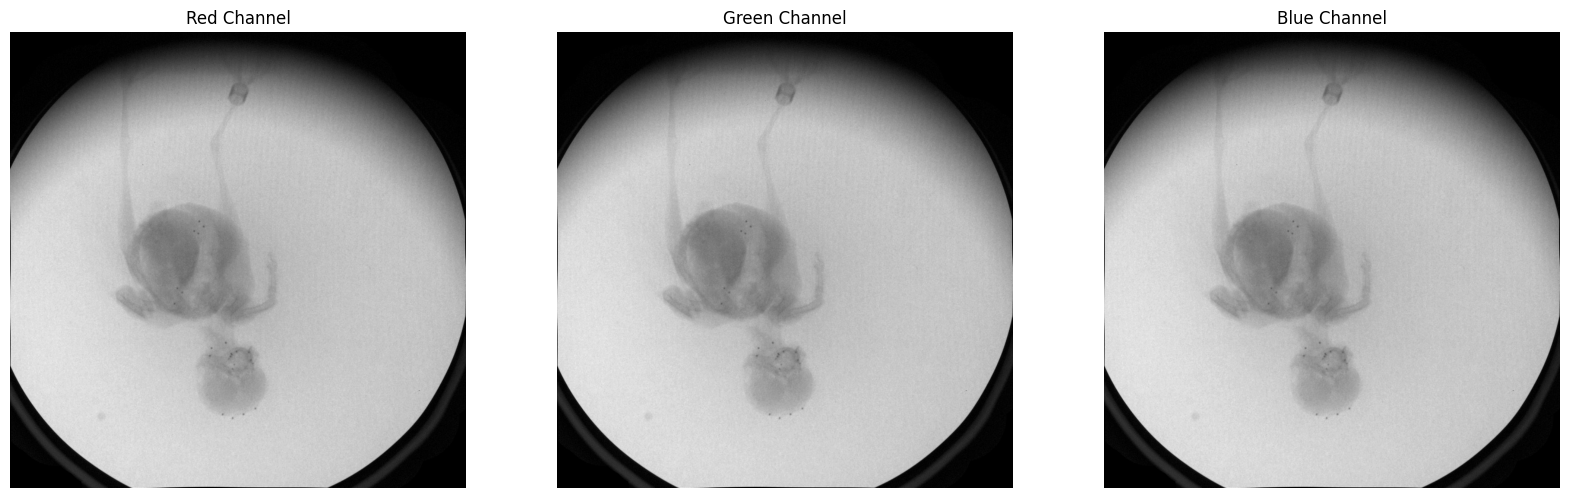

In [23]:
r, g, b = cv2.split(sample_img)
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].imshow(r, cmap='gray')
ax[0].set_title("Red Channel")

ax[1].imshow(g, cmap='gray')
ax[1].set_title("Green Channel")

ax[2].imshow(b, cmap='gray')
ax[2].set_title("Blue Channel")

for a in ax: a.axis('off')
plt.show()

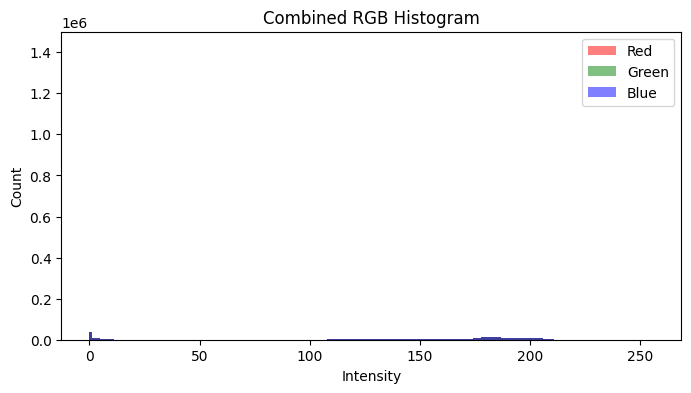

In [24]:
plt.figure(figsize=(8, 4))

plt.hist(r.ravel(), 256, range=[0, 256], color='red', alpha=0.5, label='Red')
plt.hist(g.ravel(), 256, range=[0, 256], color='green', alpha=0.5, label='Green')
plt.hist(b.ravel(), 256, range=[0, 256], color='blue', alpha=0.5, label='Blue')
plt.ylim(0,1.5e6)

plt.title("Combined RGB Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.legend()
plt.show()

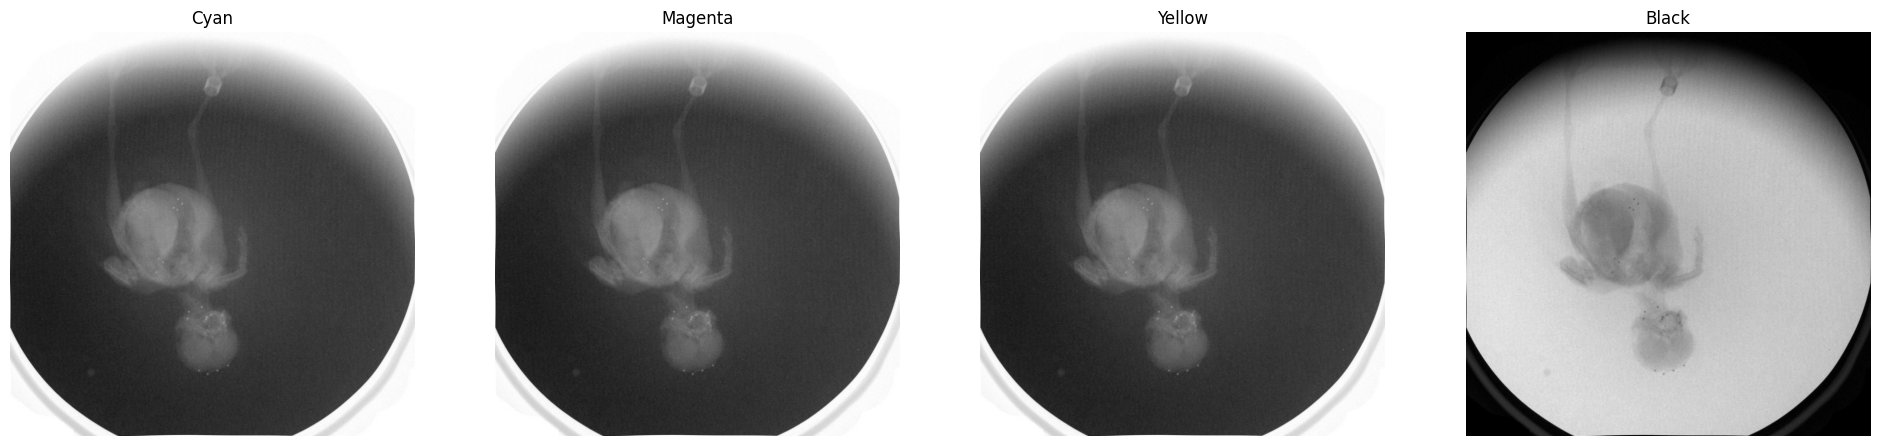

In [26]:
c = 255 - r
m = 255 - g
y = 255 - b
k = np.min(sample_img, axis=2)

fig, ax = plt.subplots(1, 4, figsize=(24, 6))

ax[0].imshow(c, cmap='gray')
ax[0].set_title("Cyan")

ax[1].imshow(m, cmap='gray')
ax[1].set_title("Magenta")

ax[2].imshow(y, cmap='gray')
ax[2].set_title("Yellow")

ax[3].imshow(k, cmap='gray')
ax[3].set_title("Black")

for a in ax: a.axis('off')
plt.show()

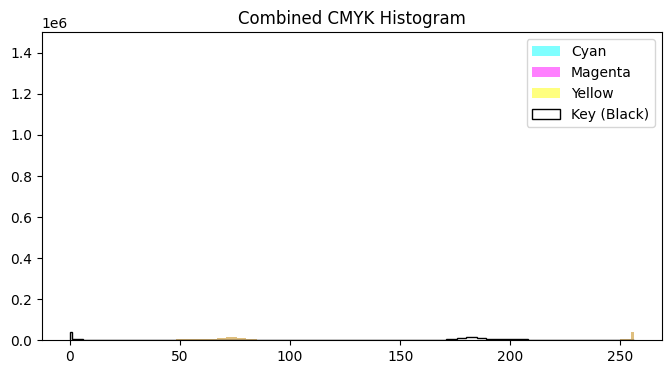

In [27]:
plt.figure(figsize=(8, 4))

plt.hist(c.ravel(), 256, range=[0, 256], color='cyan', alpha=0.5, label='Cyan')
plt.hist(m.ravel(), 256, range=[0, 256], color='magenta', alpha=0.5, label='Magenta')
plt.hist(y.ravel(), 256, range=[0, 256], color='yellow', alpha=0.5, label='Yellow')
plt.hist(k.ravel(), 256, range=[0, 256], color='black', histtype='step', label='Key (Black)')
plt.ylim(0,1.5e6)
plt.title("Combined CMYK Histogram")
plt.legend()
plt.show()

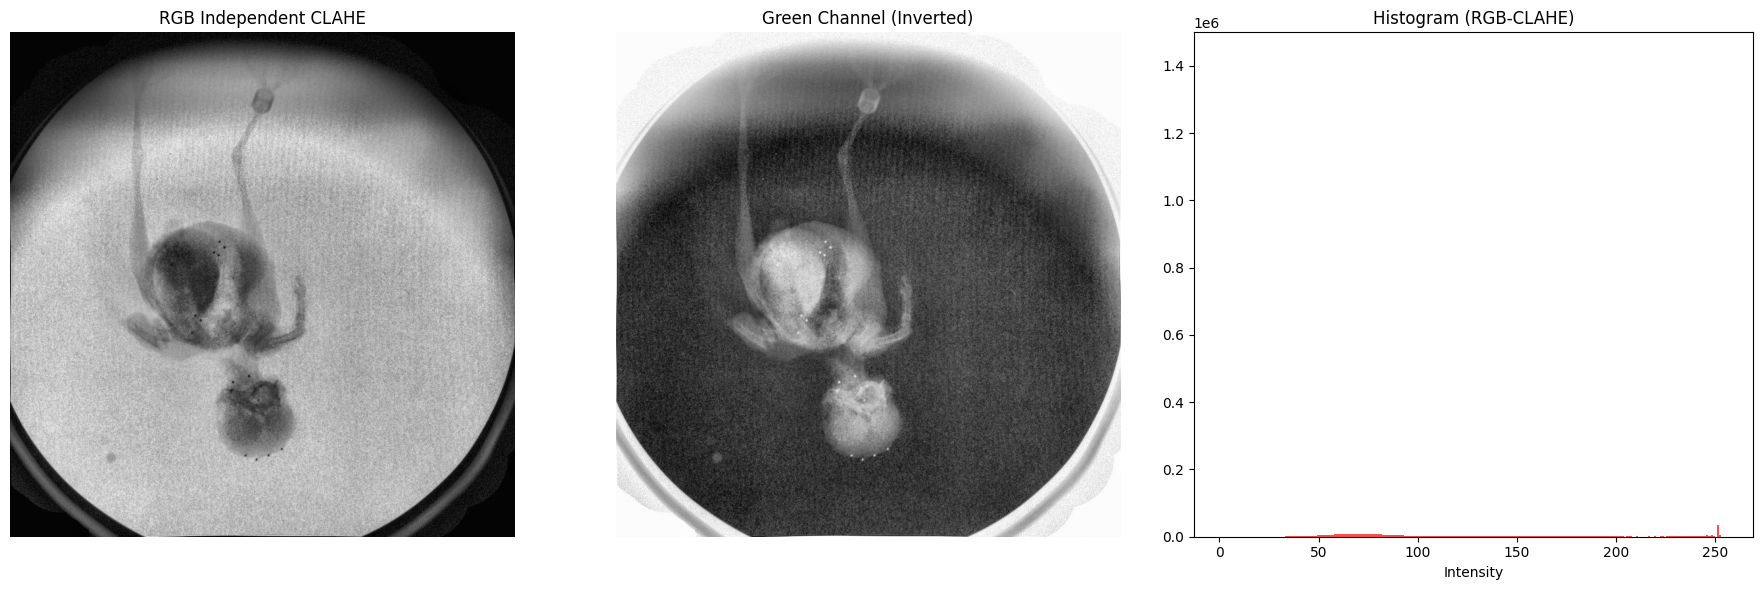

In [30]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))

r_c = clahe.apply(sample_img[:, :, 0])
g_c = clahe.apply(sample_img[:, :, 1])
b_c = clahe.apply(sample_img[:, :, 2])

rgb_clahe_all = cv2.merge((r_c, g_c, b_c))
feature_rgb_clahe = 255 - g_c  

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(rgb_clahe_all)
ax[0].set_title("RGB Independent CLAHE")
ax[0].axis('off')

ax[1].imshow(feature_rgb_clahe, cmap='gray')
ax[1].set_title("Green Channel (Inverted)")
ax[1].axis('off')

# Histogram
ax[2].hist(feature_rgb_clahe.ravel(), 256, range=[0, 256], color='red', alpha=0.7)
ax[2].set_title("Histogram (RGB-CLAHE)")
ax[2].set_xlabel("Intensity")
ax[2].set_ylim(0,1.5e6)

plt.tight_layout()
plt.show()

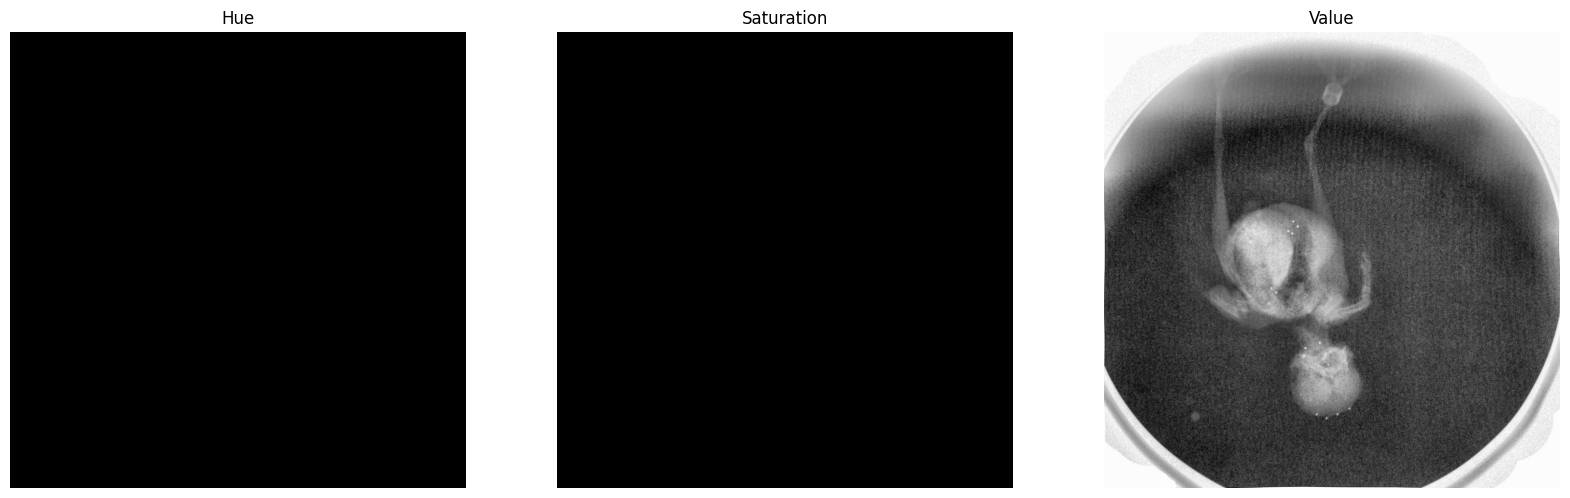

In [31]:
hsv = cv2.cvtColor(rgb_clahe_all, cv2.COLOR_RGB2HSV)
h_ch, s_ch, v_ch = cv2.split(hsv)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].imshow(h_ch, cmap='gray')
ax[0].set_title("Hue")

ax[1].imshow(s_ch, cmap='gray')
ax[1].set_title("Saturation")

ax[2].imshow(255 - v_ch, cmap='gray')
ax[2].set_title("Value")

for a in ax: a.axis('off')
plt.show()

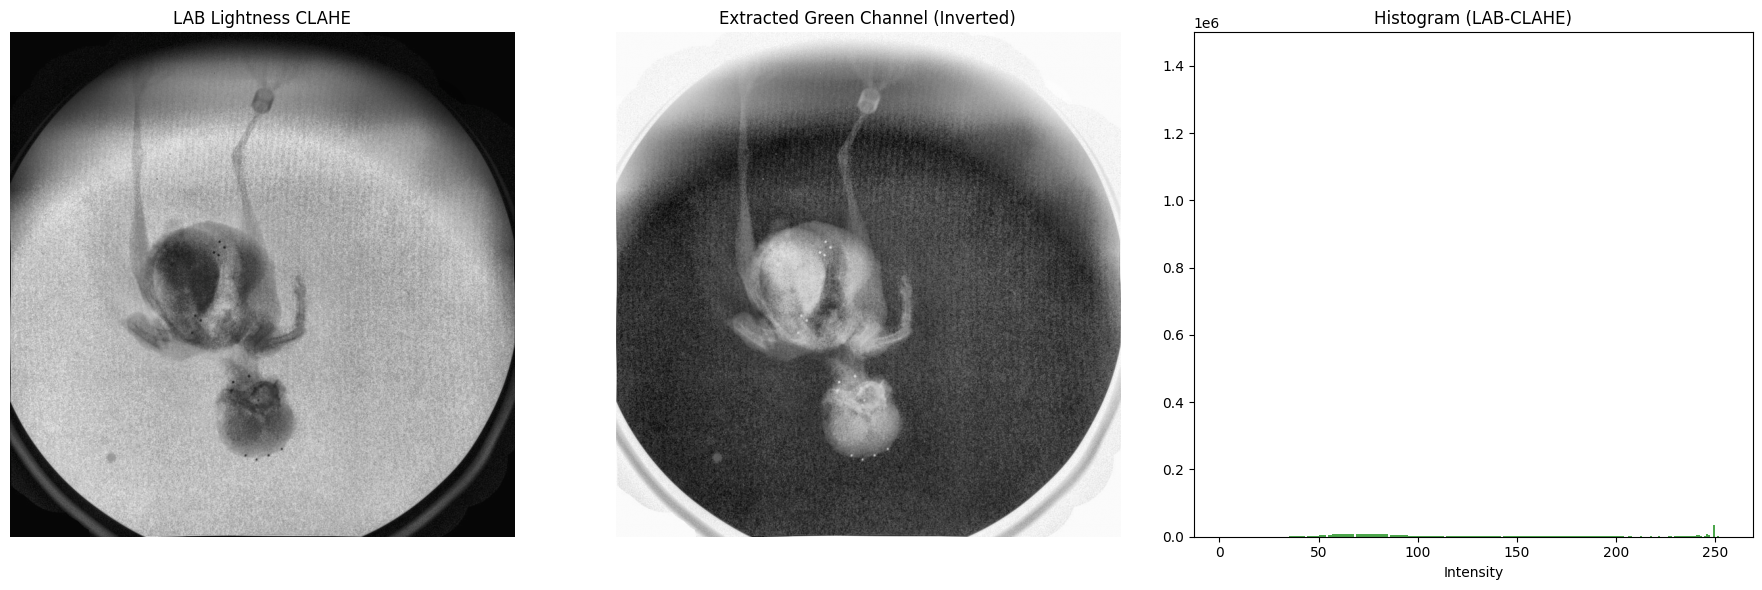

In [32]:
lab = cv2.cvtColor(sample_img, cv2.COLOR_RGB2LAB)
l, a, b_ch = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
l_enhanced = clahe.apply(l)

lab_enhanced = cv2.merge((l_enhanced, a, b_ch))
rgb_clahe_lab = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)

feature_lab_clahe = 255 - rgb_clahe_lab[:, :, 1]

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(rgb_clahe_lab)
ax[0].set_title("LAB Lightness CLAHE")
ax[0].axis('off')

ax[1].imshow(feature_lab_clahe, cmap='gray')
ax[1].set_title("Extracted Green Channel (Inverted)")
ax[1].axis('off')

# Histogram
ax[2].hist(feature_lab_clahe.ravel(), 256, range=[0, 256], color='green', alpha=0.7)
ax[2].set_title("Histogram (LAB-CLAHE)")
ax[2].set_xlabel("Intensity")
ax[2].set_ylim(0,1.5e6)

plt.tight_layout()
plt.show()

# Final Choice of Channel

## Green Inverted after CLAHE

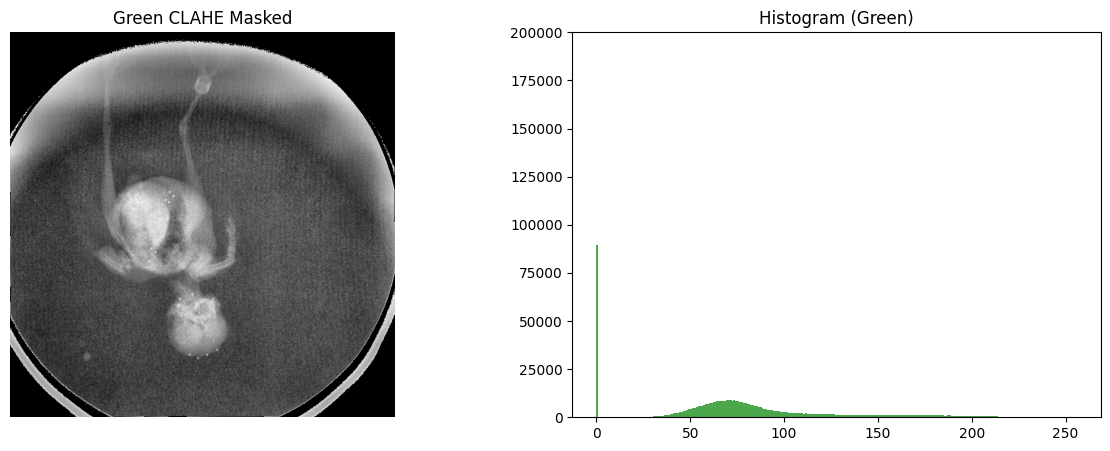

In [33]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
g_c = clahe.apply(sample_img[:, :, 1])

green_inverted = 255 - g_c

gray = cv2.cvtColor(sample_img, cv2.COLOR_RGB2GRAY)
_, roi_mask = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

img_green = cv2.bitwise_and(green_inverted, green_inverted, mask=roi_mask)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].imshow(img_green, cmap='gray')
ax[0].set_title("Green CLAHE Masked")
ax[0].axis('off')

ax[1].hist(img_green.ravel(), 256, range=[0, 256], color='green', alpha=0.7)
ax[1].set_title("Histogram (Green)")
ax[1].set_ylim(0, 0.2e6) 

plt.show()


# Super Res

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
def fft_zero_pad_superres(image, scale=2):

    rows, cols = image.shape

    new_rows = rows * scale
    new_cols = cols * scale

    # Forward FFT
    F = np.fft.fftshift(np.fft.fft2(image))

    # Zero-padded spectrum
    F_pad = np.zeros((new_rows, new_cols), dtype=complex)

    r0 = (new_rows - rows) // 2
    c0 = (new_cols - cols) // 2

    F_pad[r0:r0+rows, c0:c0+cols] = F

    # Inverse FFT
    upsampled = np.fft.ifft2(np.fft.ifftshift(F_pad))

    # Energy correction
    upsampled *= scale**2

    return np.real(upsampled)

In [5]:
img = Image.open(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T17\Canari-Tyler-2026-05-22\labeled-data\n200\TrainingData_T17_cam1_0009.png").convert("L")

image = np.asarray(img, dtype=np.float64)

In [8]:
sr = fft_zero_pad_superres(image, scale=2)

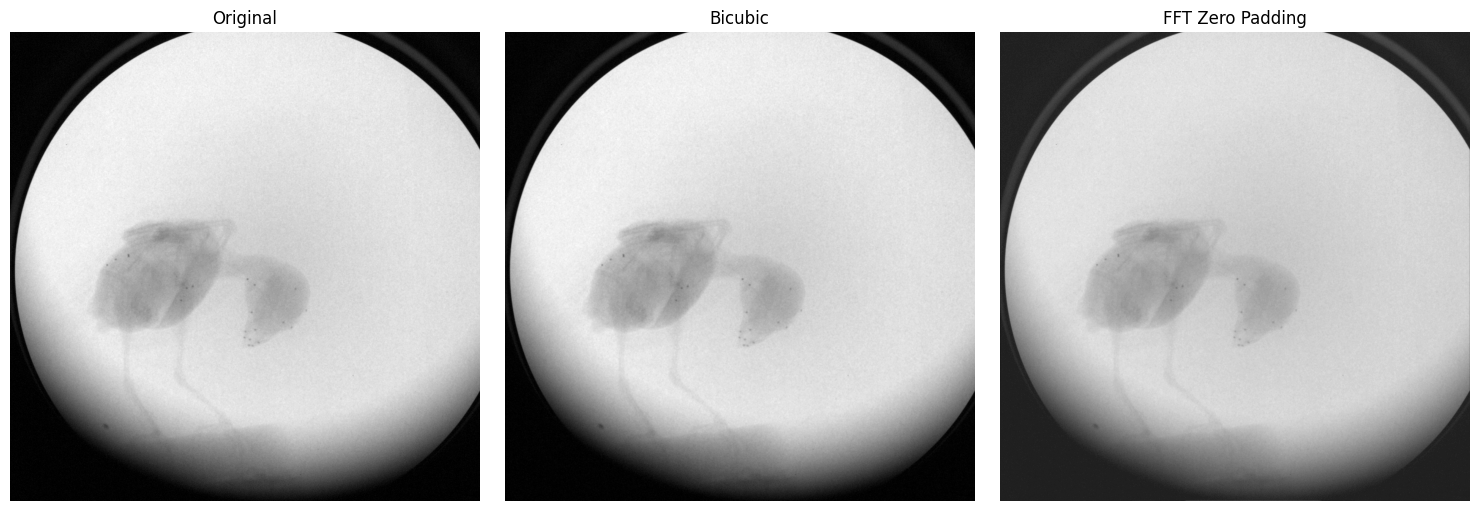

In [9]:
from PIL import Image

bicubic = np.array(
    Image.fromarray(image.astype(np.uint8)).resize(
        (image.shape[1]*2, image.shape[0]*2),
        Image.Resampling.BICUBIC
    )
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bicubic, cmap="gray")
plt.title("Bicubic")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sr, cmap="gray")
plt.title("FFT Zero Padding")
plt.axis("off")

plt.tight_layout()
plt.show()

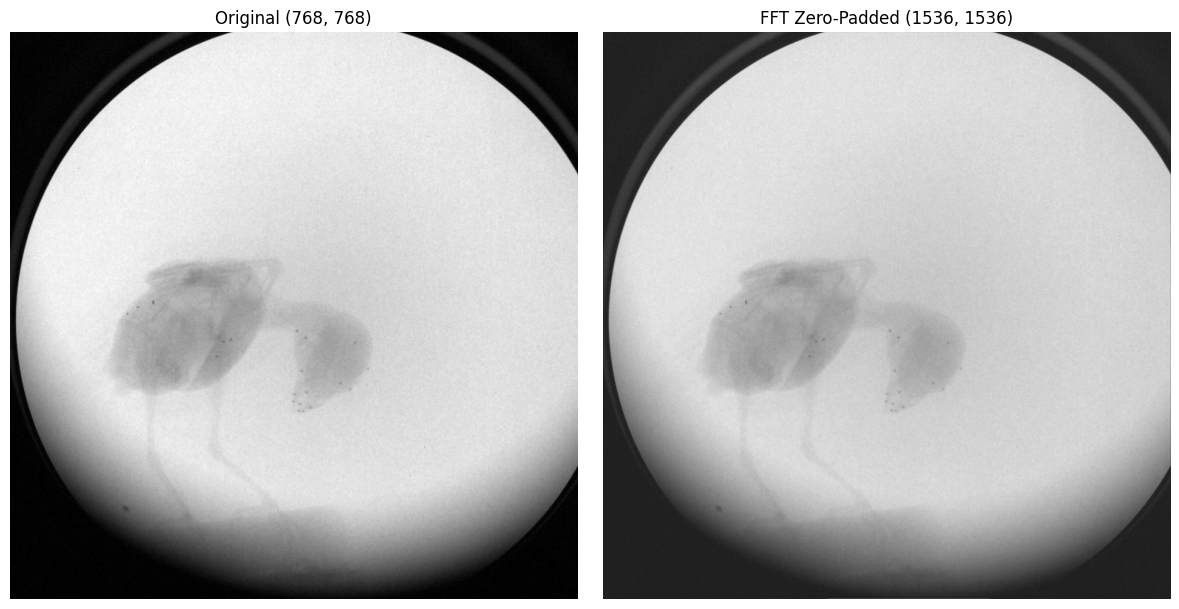

In [12]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title(f"Original {image.shape}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sr, cmap="gray")
plt.title(f"FFT Zero-Padded {sr.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:

from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter
from skimage.feature import blob_dog


In [13]:
# Remove background
background = gaussian_filter(image, sigma=20)
hp = background - image          # dark spots become bright

# Normalize
hp = (hp - hp.min()) / (hp.max() - hp.min())

blobs = blob_dog(
    hp,
    min_sigma=1,
    max_sigma=2,
    sigma_ratio=1.3,
    threshold=0.03,
    overlap=0.5,
)

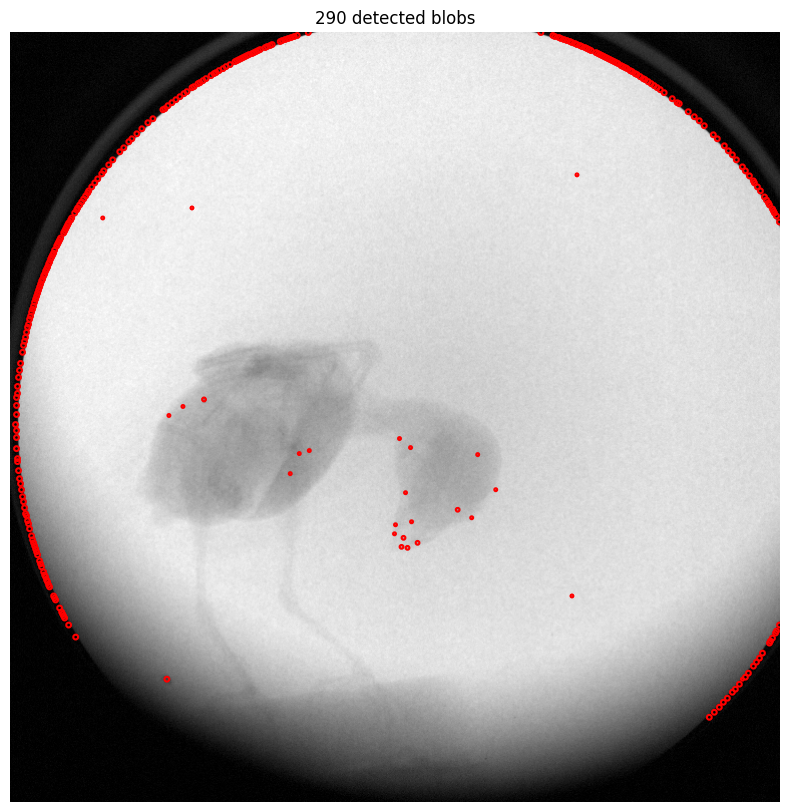

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(image, cmap="gray")

for y, x, sigma in blobs:
    r = sigma * np.sqrt(2)
    ax.add_patch(
        Circle(
            (x, y),
            r,
            edgecolor="red",
            facecolor="none",
            linewidth=1.5,
        )
    )

ax.set_title(f"{len(blobs)} detected blobs")
ax.axis("off")
plt.show()

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from skimage.io import imread
from skimage.feature import blob_dog
from matplotlib.patches import Circle
from skimage import img_as_float


INPUT_DIR = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\ActiveUpdates\Trial2\dino\cam1")
OUTPUT_DIR = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\ActiveUpdates\Trial2\blobdetections")
OUTPUT_DIR.mkdir(exist_ok=True)

records = []

for frame_idx, img_path in enumerate(sorted(INPUT_DIR.glob("*.jpg"))):
    
    image = img_as_float(imread(img_path, as_gray=True))

    # Background removal
    bg = gaussian_filter(image, sigma=20)
    hp = bg - image

    hp -= hp.min()
    hp /= hp.max()

    blobs = blob_dog(
        hp,
        min_sigma=1,
        max_sigma=3,
        sigma_ratio=1.3,
        threshold=0.03
    )

    # Save detections
    for blob_id, (y, x, sigma) in enumerate(blobs):
        records.append({
            "frame": frame_idx,
            "blob_id": blob_id,
            "x": x,
            "y": y,
            "sigma": sigma
        })

    # Create labeled image
    fig, ax = plt.subplots(figsize=(8,8))
    ax.imshow(image, cmap="gray")

    for blob_id, (y, x, sigma) in enumerate(blobs):

        r = sigma * np.sqrt(2)

        ax.add_patch(
            Circle(
                (x, y),
                r,
                edgecolor="red",
                facecolor="none",
                linewidth=1
            )
        )

        ax.text(
            x,
            y,
            str(blob_id),
            color="yellow",
            fontsize=6
        )

    ax.axis("off")

    plt.savefig(
        OUTPUT_DIR / f"{img_path.stem}_labeled.png",
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close()

pd.DataFrame(records).to_csv(
    "detections.csv",
    index=False
)

In [21]:
records = pd.DataFrame(records)

In [23]:
import trackpy as tp
tracks = tp.link(records, search_range=2)

Frame 29: 225 trajectories present.


In [24]:
print(tracks)

      frame  blob_id      x      y   sigma  particle
0         0        0  293.0    0.0  2.8561         0
133       0      133   10.0  328.0  2.1970         1
134       0      134    9.0  335.0  2.1970         2
135       0      135    8.0  343.0  2.1970         3
136       0      136  382.0  299.0  1.0000         4
...     ...      ...    ...    ...     ...       ...
6513     29       79   27.0  259.0  2.1970      2025
6514     29       80   25.0  263.0  2.8561      2221
6515     29       81   25.0  267.0  1.6900      2298
6488     29       54   57.0  193.0  1.6900      2299
6658     29      224   38.0  552.0  2.8561      2300

[6659 rows x 6 columns]


In [26]:
from pathlib import Path
import matplotlib.pyplot as plt
from skimage.io import imread
import ipywidgets as widgets
from IPython.display import display

image_files = sorted(Path(INPUT_DIR).glob("*.jpg"))

def show_frame(frame_idx):

    img = imread(image_files[frame_idx], as_gray=True)

    fig, ax = plt.subplots(figsize=(8,8))
    ax.imshow(img, cmap="gray")

    # current frame detections
    current = tracks[tracks.frame == frame_idx]

    ax.scatter(
        current.x,
        current.y,
        c="red",
        s=30
    )

    # trajectories up to this frame
    for pid in tracks.particle.unique():

        tr = tracks[
            (tracks.particle == pid) &
            (tracks.frame <= frame_idx)
        ]

        if len(tr) > 1:
            ax.plot(
                tr.x,
                tr.y,
                linewidth=2
            )

    ax.set_title(f"Frame {frame_idx}")
    ax.axis("off")

    plt.show()

widgets.interact(
    show_frame,
    frame_idx=(0, len(image_files)-1)
)

interactive(children=(IntSlider(value=14, description='frame_idx', max=29), Output()), _dom_classes=('widget-i…

<function __main__.show_frame(frame_idx)>

In [32]:
ROI_XMIN = 100
ROI_XMAX = 600
ROI_YMIN = 100
ROI_YMAX = 600

def in_roi(df):
    return df[
        (df.x >= ROI_XMIN) &
        (df.x <= ROI_XMAX) &
        (df.y >= ROI_YMIN) &
        (df.y <= ROI_YMAX)
    ]

def show_frame(frame_idx):

    img = imread(image_files[frame_idx], as_gray=True)

    fig, ax = plt.subplots(figsize=(8,8))
    ax.imshow(img, cmap="gray")

    # current frame detections
    current = in_roi(
        tracks[tracks.frame == frame_idx]
    )

    ax.scatter(
        current.x,
        current.y,
        c="red",
        s=30
    )

    # trajectories
    for pid in tracks.particle.unique():

        tr = tracks[
            (tracks.particle == pid) &
            (tracks.frame <= frame_idx)
        ]

        tr = in_roi(tr)

        if len(tr) > 1:
            ax.plot(
                tr.x,
                tr.y,
                linewidth=2
            )

    # zoom to ROI
    ax.set_xlim(ROI_XMIN, ROI_XMAX)
    ax.set_ylim(ROI_YMAX, ROI_YMIN)  # image coordinates

    ax.set_title(f"Frame {frame_idx}")
    ax.axis("off")

    plt.show()

In [33]:
particles_in_roi = tracks[
    (tracks.frame == tracks.frame.min()) &
    (tracks.x >= 100) & (tracks.x <= 600) &
    (tracks.y >= 100) & (tracks.y <= 600)
].particle.unique()

In [34]:
def show_frame(frame_idx):

    img = imread(image_files[frame_idx], as_gray=True)

    fig, ax = plt.subplots(figsize=(8,8))
    ax.imshow(img, cmap="gray")

    # current frame detections
    current = tracks[tracks.frame == frame_idx]

    ax.scatter(
        current.x,
        current.y,
        c="red",
        s=30
    )

    # trajectories up to this frame
    for pid in particles_in_roi:

        tr = tracks[
            (tracks.particle == pid) &
            (tracks.frame <= frame_idx)
        ]

        if len(tr) > 1:
            ax.plot(
                tr.x,
                tr.y,
                linewidth=2
            )

    ax.set_title(f"Frame {frame_idx}")
    ax.axis("off")

    plt.show()

widgets.interact(
    show_frame,
    frame_idx=(0, len(image_files)-1)
)

interactive(children=(IntSlider(value=14, description='frame_idx', max=29), Output()), _dom_classes=('widget-i…

<function __main__.show_frame(frame_idx)>

# Segmentation Methods Comparing

In [6]:
gt_path = 'NIH-NLM-ThinBloodSmearsPf/Polygon Set/209C68P29N_ThinF/GT/IMG_20150819_133236.txt'
print(f"{int(open(gt_path).readline().split(',')[0])} GT points")

218 GT points


In [7]:
def overlay_blue_mask(img_rgb, mask, alpha=0.4):
    blue_layer = np.zeros_like(img_rgb)
    blue_layer[mask > 0] = [0, 0, 255]
    
    out = img_rgb.copy()
    roi = mask > 0
    if roi.any():
        out[roi] = cv2.addWeighted(img_rgb[roi], 1-alpha, blue_layer[roi], alpha, 0).squeeze()
    return out

def visualize_grid(img_input, img_rgb, method_func, params_list, title_main):
    n = len(params_list)
    cols = 4
    rows = (n + cols - 1) // cols
    actual_cols = min(n, cols)
    
    fig, axes = plt.subplots(rows, actual_cols, figsize=(4 * actual_cols, 5 * rows))
    
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, params in enumerate(params_list):
        res_img, count = method_func(img_input, img_rgb, **params)
        param_str = "\n".join([f"{k}={v}" for k, v in params.items()])
        
        axes[i].imshow(res_img)
        axes[i].set_title(f"Obj: {count}\n{param_str}", fontsize=9)
        axes[i].axis('off')
        
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle(title_main, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [8]:
def segment_otsu(img_gray, img_rgb_ref, blur_ksize=0, morph_kernel_size=0, min_area=50):
    if blur_ksize > 0:
        if blur_ksize % 2 == 0: blur_ksize += 1
        img_proc = cv2.GaussianBlur(img_gray, (blur_ksize, blur_ksize), 0)
    else:
        img_proc = img_gray

    _, binary = cv2.threshold(img_proc, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    if morph_kernel_size > 0:
        kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
    
    clean_mask = np.zeros_like(binary)
    valid_count = 0
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_area:
            clean_mask[labels == i] = 255
            valid_count += 1
            
    vis_img = overlay_blue_mask(img_rgb_ref, clean_mask, alpha=0.4)
    return vis_img, valid_count

def segment_watershed(img_gray, img_rgb_ref, blur_ksize=0, morph_kernel_size=3, dist_mask_size=5, dist_thresh_ratio=0.5, min_area=50):
    if blur_ksize > 0:
        if blur_ksize % 2 == 0: blur_ksize += 1
        img_proc = cv2.GaussianBlur(img_gray, (blur_ksize, blur_ksize), 0)
    else:
        img_proc = img_gray
        
    _, binary = cv2.threshold(img_proc, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    if morph_kernel_size > 0:
        kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
        closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
        opening = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel, iterations=2)
    else:
        opening = binary
        kernel = np.ones((3, 3), np.uint8)

    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, dist_mask_size)
    
    if dist_transform.max() == 0: return img_rgb_ref.copy(), 0
    
    _, sure_fg = cv2.threshold(dist_transform, dist_thresh_ratio * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    
    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(img_rgb_ref, markers)
    
    unique, counts = np.unique(markers, return_counts=True)
    
    valid_labels = []
    for label, count in zip(unique, counts):
        if label > 1 and count > min_area:
            valid_labels.append(label)
            
    object_mask = np.isin(markers, valid_labels).astype(np.uint8) * 255
    
    vis_img = overlay_blue_mask(img_rgb_ref, object_mask, alpha=0.4)
    return vis_img, len(valid_labels)

def segment_hough(img_gray, img_rgb_ref, blur_ksize=5, dp=1.2, minDist=25, param1=50, param2=30, min_radius=15):
    if blur_ksize > 0 and blur_ksize % 2 == 0: blur_ksize += 1
        
    if blur_ksize > 0:
        blur = cv2.medianBlur(img_gray, blur_ksize)
    else:
        blur = img_gray
    
    circles = cv2.HoughCircles(
        blur, cv2.HOUGH_GRADIENT, dp=dp, minDist=minDist,
        param1=param1, param2=param2, minRadius=min_radius, maxRadius=80
    )
    
    vis_img = img_rgb_ref.copy()
    count = 0
    if circles is not None:
        circles = np.uint16(np.around(circles))
        count = circles.shape[1]
        for i in circles[0, :]:
            cv2.circle(vis_img, (i[0], i[1]), i[2], (0, 0, 255), 2)
            
    return vis_img, count

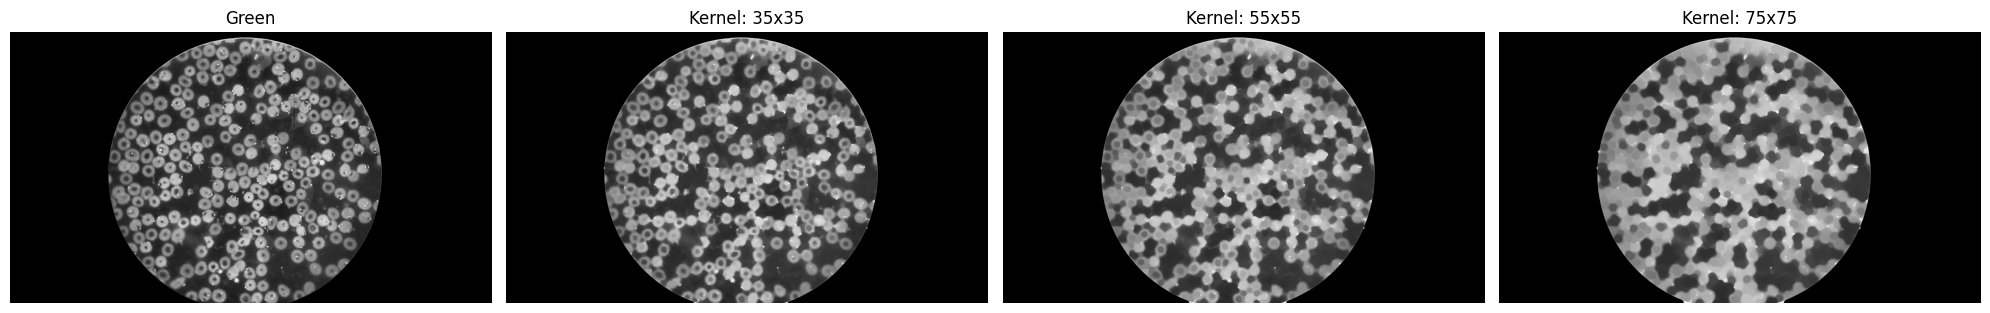

In [21]:
def gray_morphology(img_rgb):    
    kernel_sizes = [35, 55, 75]
    
    plt.figure(figsize=(20, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb, cmap='gray')
    plt.title("Green")
    plt.axis('off')
    
    for i, k_size in enumerate(kernel_sizes):
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_size, k_size))
        closed = cv2.morphologyEx(img_rgb, cv2.MORPH_CLOSE, kernel)
        
        plt.subplot(1, 4, i + 2)
        plt.imshow(closed, cmap='gray')
        plt.title(f"Kernel: {k_size}x{k_size}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

gray_morphology(img_green)


## Watershed Grid

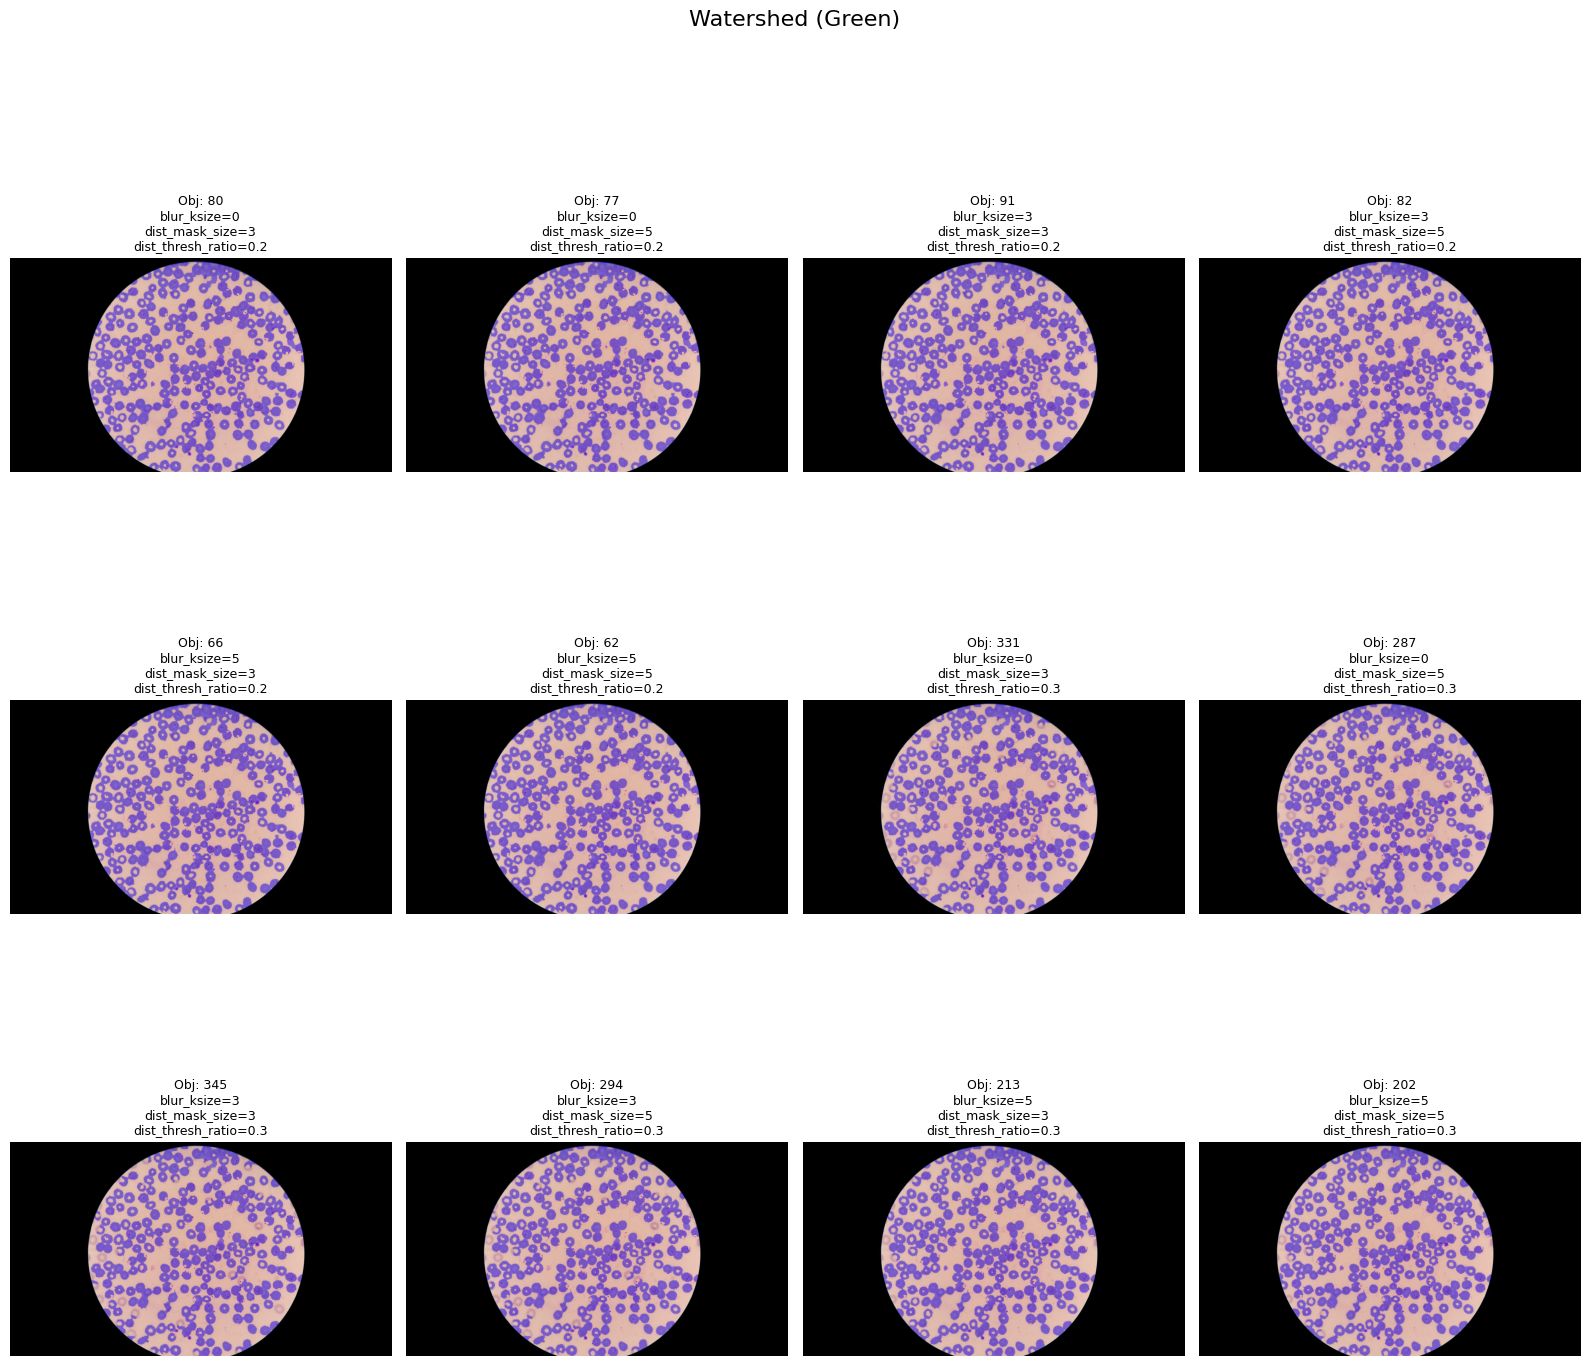

In [125]:
water_grid = [
    {"blur_ksize": 0, "dist_mask_size": 3, "dist_thresh_ratio": 0.2},
    {"blur_ksize": 0, "dist_mask_size": 5, "dist_thresh_ratio": 0.2},
    {"blur_ksize": 3, "dist_mask_size": 3, "dist_thresh_ratio": 0.2},
    {"blur_ksize": 3, "dist_mask_size": 5, "dist_thresh_ratio": 0.2},
    {"blur_ksize": 5, "dist_mask_size": 3, "dist_thresh_ratio": 0.2},
    {"blur_ksize": 5, "dist_mask_size": 5, "dist_thresh_ratio": 0.2},
    {"blur_ksize": 0, "dist_mask_size": 3, "dist_thresh_ratio": 0.3},
    {"blur_ksize": 0, "dist_mask_size": 5, "dist_thresh_ratio": 0.3},
    {"blur_ksize": 3, "dist_mask_size": 3, "dist_thresh_ratio": 0.3},
    {"blur_ksize": 3, "dist_mask_size": 5, "dist_thresh_ratio": 0.3},
    {"blur_ksize": 5, "dist_mask_size": 3, "dist_thresh_ratio": 0.3},
    {"blur_ksize": 5, "dist_mask_size": 5, "dist_thresh_ratio": 0.3},
]
visualize_grid(img_green, rgb, segment_watershed, water_grid, "Watershed (Green)")